In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

In [4]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [5]:
def select_features(X_train,X_test,y_train):

    selector = ExtraTreesClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=42
    )

    selector.fit(X_train,y_train)

    importances = selector.feature_importances_

    top_features = np.argsort(importances)[-20:]

    X_train = X_train.iloc[:,top_features]
    X_test = X_test.iloc[:,top_features]

    return X_train,X_test

In [6]:
def train_models(X_train,y_train,X_test,y_test,dataset_name):

    models = {

    "DecisionTree":(
        DecisionTreeClassifier(),
        {
        "max_depth":[10,20,None],
        "min_samples_split":[2,5,10]
        }
    ),

    "RandomForest":(
        RandomForestClassifier(n_jobs=-1),
        {
        "n_estimators":[100,200],
        "max_depth":[10,20,None]
        }
    ),

    "LogisticRegression":(
        LogisticRegression(max_iter=500),
        {
        "C":[0.01,0.1,1,10]
        }
    ),

    "GradientBoosting":(
        GradientBoostingClassifier(),
        {
        "n_estimators":[100,200],
        "learning_rate":[0.01,0.1],
        "max_depth":[3,5]
        }
    ),

    "XGBoost":(
        XGBClassifier(
            tree_method="hist", 
            device="cuda",
            predictor="gpu_predictor",
            eval_metric="logloss"
        ),
        {
        "n_estimators":[100,200],
        "learning_rate":[0.01,0.1],
        "max_depth":[3,6]
        }
    )

    }


    results = {}

    for name,(model,params) in models.items():

        print("\n======================")
        print("Training:",name,"on",dataset_name)
        print("======================")

        grid = GridSearchCV(
            model,
            params,
            cv=cv,          # 10 fold CV here
            scoring="f1",
            n_jobs=-1
        )

        grid.fit(X_train,y_train)

        best_model = grid.best_estimator_

        preds = best_model.predict(X_test)

        print("Best Parameters:",grid.best_params_)

        print(classification_report(y_test,preds))


        cm = confusion_matrix(y_test,preds)

        plt.figure()

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues"
        )

        plt.title(name+" Confusion Matrix ("+dataset_name+")")

        plt.show()


        auc = roc_auc_score(y_test,preds)

        results[name] = auc

    return results

In [7]:
def run_pipeline(train_path,test_path,dataset_name):

    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)

    X_train = train.drop("label",axis=1)
    y_train = train["label"]

    X_test = test.drop("label",axis=1)
    y_test = test["label"]

    # Feature selection
    X_train,X_test = select_features(X_train,X_test,y_train)

    results = train_models(
        X_train,
        y_train,
        X_test,
        y_test,
        dataset_name
    )

    return results


Training: DecisionTree on NSL-KDD
Best Parameters: {'max_depth': None, 'min_samples_split': 5}
              precision    recall  f1-score   support

           0       0.66      0.97      0.78      9711
           1       0.96      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.77     22544



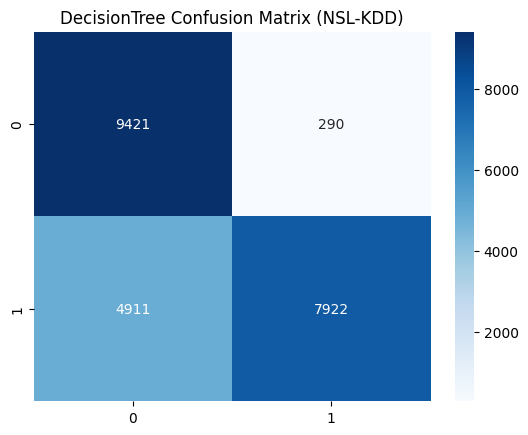


Training: RandomForest on NSL-KDD
Best Parameters: {'max_depth': None, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.66      0.97      0.79      9711
           1       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544



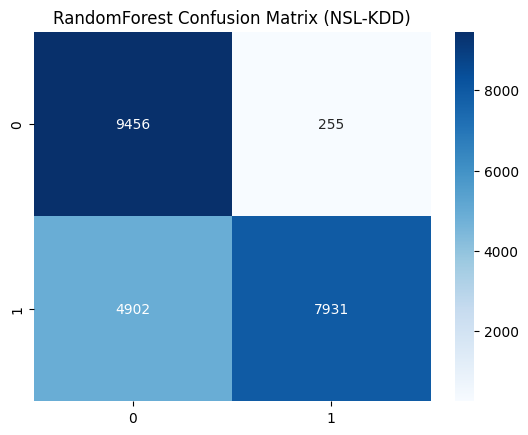


Training: LogisticRegression on NSL-KDD
Best Parameters: {'C': 0.01}
              precision    recall  f1-score   support

           0       0.63      0.92      0.75      9711
           1       0.91      0.60      0.72     12833

    accuracy                           0.74     22544
   macro avg       0.77      0.76      0.74     22544
weighted avg       0.79      0.74      0.73     22544



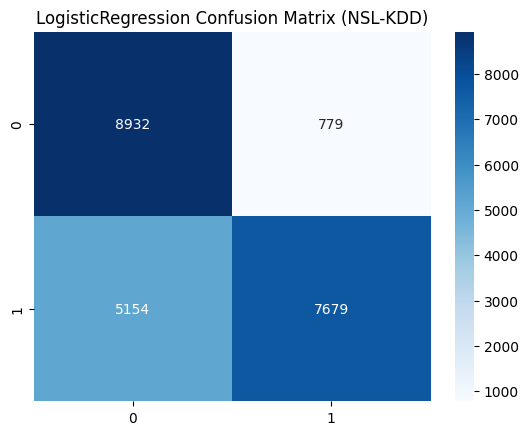


Training: GradientBoosting on NSL-KDD
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.66      0.96      0.79      9711
           1       0.96      0.63      0.76     12833

    accuracy                           0.78     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.78      0.77     22544



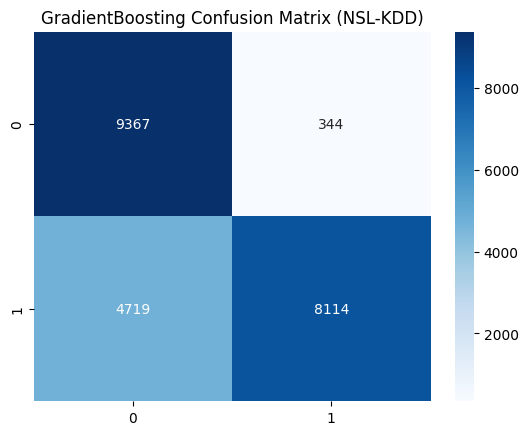


Training: XGBoost on NSL-KDD


c:\Users\ashmit\.conda\envs\pytorch\lib\site-packages\xgboost\training.py:200: UserWarning: [23:53:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.67      0.97      0.80      9711
           1       0.97      0.64      0.77     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.78     22544



c:\Users\ashmit\.conda\envs\pytorch\lib\site-packages\xgboost\core.py:751: UserWarning: [23:53:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


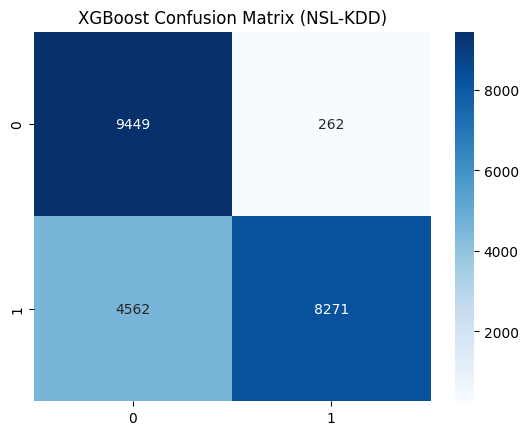

In [8]:
kdd_results = run_pipeline(
    "KDDTrain_preprocessed.csv",
    "KDDTest_preprocessed.csv",
    "NSL-KDD"
)


Training: DecisionTree on UNSW-NB15
Best Parameters: {'max_depth': 10, 'min_samples_split': 10}
              precision    recall  f1-score   support

           0       0.96      0.74      0.83     34206
           1       0.70      0.96      0.81     21739

    accuracy                           0.82     55945
   macro avg       0.83      0.85      0.82     55945
weighted avg       0.86      0.82      0.82     55945



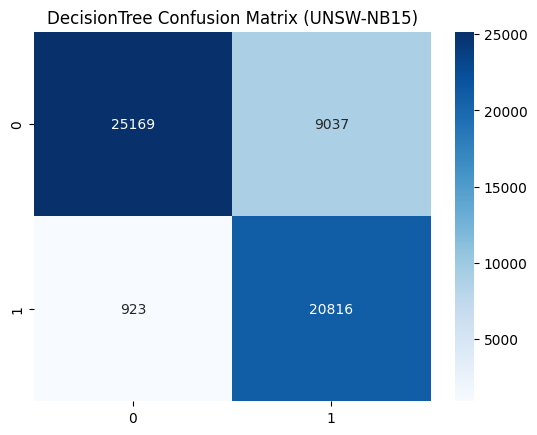


Training: RandomForest on UNSW-NB15
Best Parameters: {'max_depth': 20, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.98      0.73      0.84     34206
           1       0.70      0.98      0.81     21739

    accuracy                           0.83     55945
   macro avg       0.84      0.85      0.83     55945
weighted avg       0.87      0.83      0.83     55945



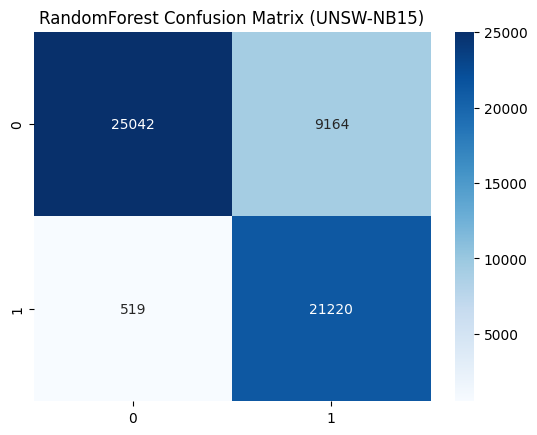


Training: LogisticRegression on UNSW-NB15
Best Parameters: {'C': 0.1}
              precision    recall  f1-score   support

           0       0.95      0.63      0.76     34206
           1       0.62      0.94      0.75     21739

    accuracy                           0.75     55945
   macro avg       0.78      0.79      0.75     55945
weighted avg       0.82      0.75      0.75     55945



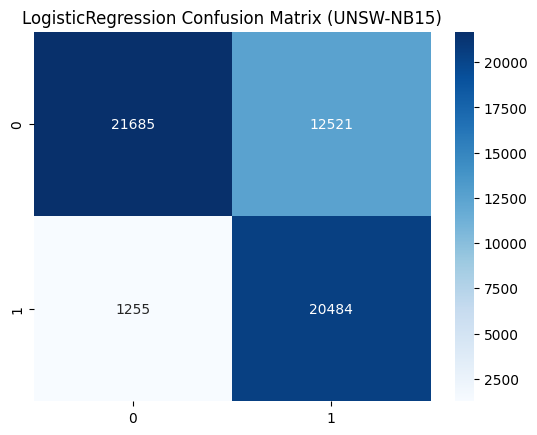


Training: GradientBoosting on UNSW-NB15
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.98      0.72      0.83     34206
           1       0.69      0.97      0.81     21739

    accuracy                           0.82     55945
   macro avg       0.83      0.85      0.82     55945
weighted avg       0.87      0.82      0.82     55945



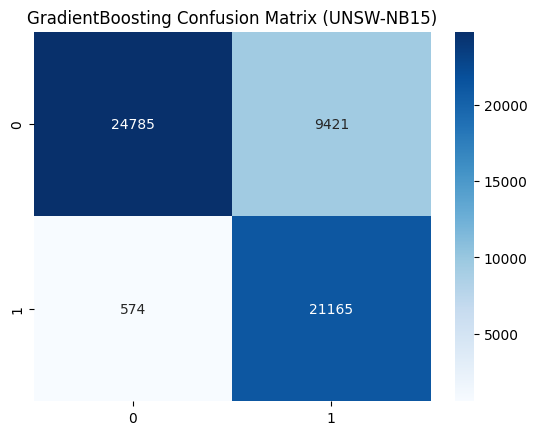


Training: XGBoost on UNSW-NB15


c:\Users\ashmit\.conda\envs\pytorch\lib\site-packages\xgboost\training.py:200: UserWarning: [00:17:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     34206
           1       0.70      0.97      0.81     21739

    accuracy                           0.83     55945
   macro avg       0.84      0.85      0.83     55945
weighted avg       0.87      0.83      0.83     55945



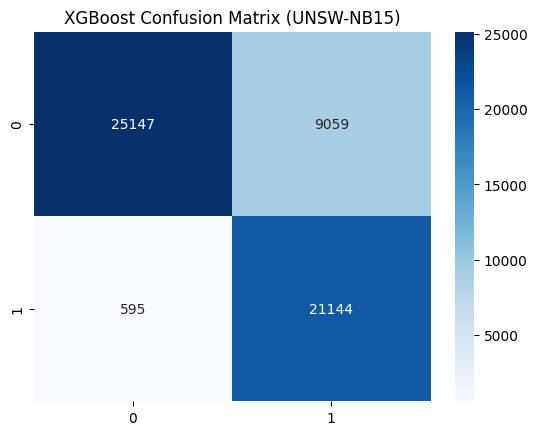

In [9]:
unsw_results = run_pipeline(
    "UNSW_train_preprocessed.csv",
    "UNSW_test_preprocessed.csv",
    "UNSW-NB15"
)


Training: DecisionTree on Hybrid Dataset
Best Parameters: {'max_depth': 20, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.86      0.78      0.82     43054
           1       0.72      0.81      0.76     29669

    accuracy                           0.79     72723
   macro avg       0.79      0.80      0.79     72723
weighted avg       0.80      0.79      0.80     72723



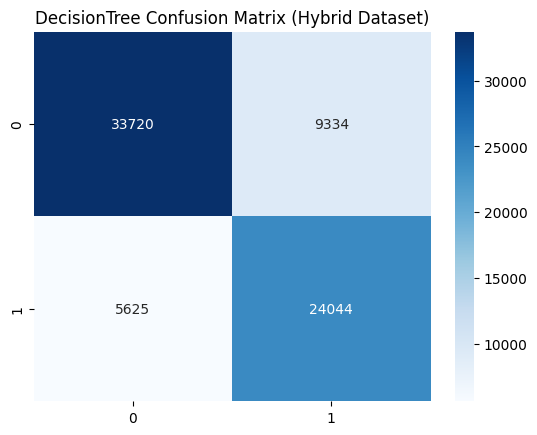


Training: RandomForest on Hybrid Dataset
Best Parameters: {'max_depth': 20, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.87      0.77      0.82     43054
           1       0.72      0.83      0.77     29669

    accuracy                           0.80     72723
   macro avg       0.79      0.80      0.79     72723
weighted avg       0.81      0.80      0.80     72723



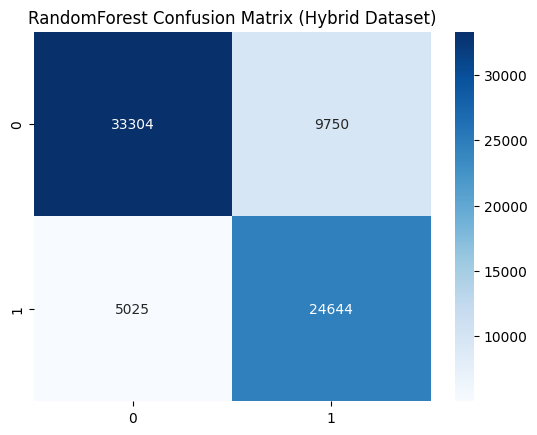


Training: LogisticRegression on Hybrid Dataset
Best Parameters: {'C': 0.1}
              precision    recall  f1-score   support

           0       0.74      0.57      0.64     43054
           1       0.53      0.70      0.61     29669

    accuracy                           0.63     72723
   macro avg       0.63      0.64      0.63     72723
weighted avg       0.65      0.63      0.63     72723



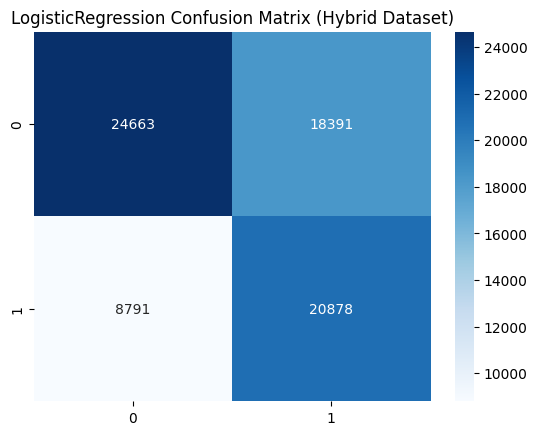


Training: GradientBoosting on Hybrid Dataset
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.88      0.77      0.82     43054
           1       0.72      0.85      0.78     29669

    accuracy                           0.80     72723
   macro avg       0.80      0.81      0.80     72723
weighted avg       0.81      0.80      0.80     72723



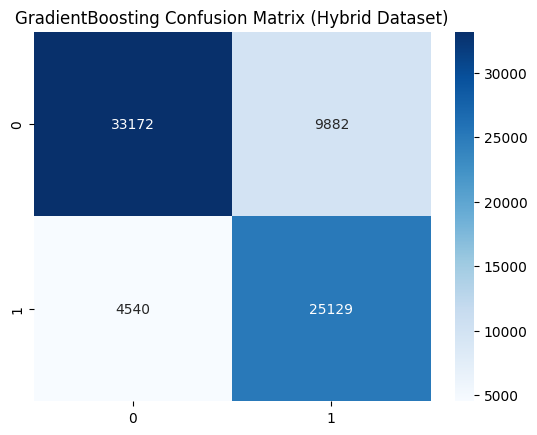


Training: XGBoost on Hybrid Dataset


c:\Users\ashmit\.conda\envs\pytorch\lib\site-packages\xgboost\training.py:200: UserWarning: [01:07:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.88      0.77      0.82     43054
           1       0.72      0.85      0.78     29669

    accuracy                           0.80     72723
   macro avg       0.80      0.81      0.80     72723
weighted avg       0.82      0.80      0.81     72723



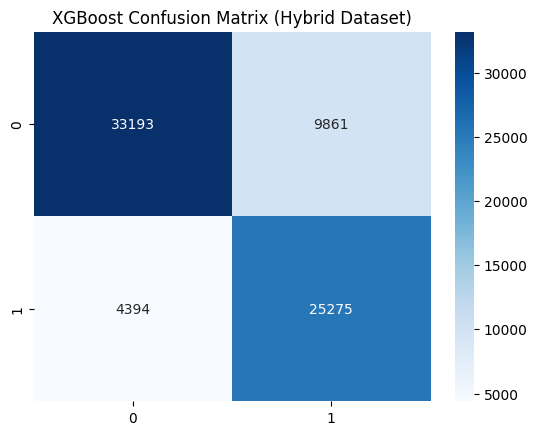

In [10]:
hybrid_results = run_pipeline(
    "Hybrid_IDS_train.csv",
    "Hybrid_IDS_test.csv",
    "Hybrid Dataset"
)

In [11]:
comparison = pd.DataFrame({

"Model":list(kdd_results.keys()),
"KDD_AUC":list(kdd_results.values()),
"UNSW_AUC":list(unsw_results.values()),
"Hybrid_AUC":list(hybrid_results.values())

})

print(comparison)

                Model   KDD_AUC  UNSW_AUC  Hybrid_AUC
0        DecisionTree  0.793726  0.846674    0.796805
1        RandomForest  0.795879  0.854110    0.802086
2  LogisticRegression  0.759080  0.788111    0.638268
3    GradientBoosting  0.798426  0.849088    0.808726
4             XGBoost  0.808765  0.853897    0.811431


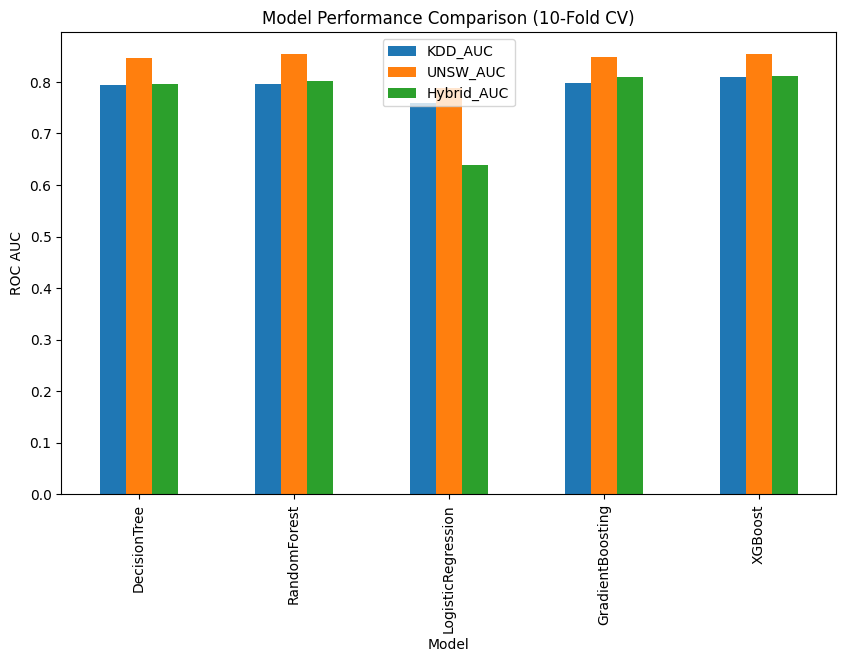

In [12]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison (10-Fold CV)")

plt.ylabel("ROC AUC")

plt.show()